In [2]:
from os import chdir
from pathlib import Path

cwd = Path.cwd()
print(f"CWD: {cwd}")
if cwd.name == "code":
    chdir("..")
print(f"CWD: {Path.cwd()}")

CWD: /Users/haowen/Documents/Decentral RS/fed-learning-main/code
CWD: /Users/haowen/Documents/Decentral RS/fed-learning-main


In [3]:
import torch
import torch.nn as nn
import numpy as np
import networkx as nx
import random
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [4]:
from general.functions import LinearModel, generate_local_data, sample_neighbors, decentralized_gd_with_sampling,  centralized_weighted_gradient_descent

In [5]:
from src.graphs import random_k_out_graph, create_graph, create_cycle_graph,create_scale_free_graph

In [6]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    # For CUDA
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # For deterministic behavior (slower)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(0)

In [7]:
def compute_theta_rmse(estimated_theta: torch.Tensor, true_theta: torch.Tensor, data_sizes) -> float:
    assert estimated_theta.shape == true_theta.shape, "Shape mismatch"
    d = true_theta.numel()
    total_n = sum(data_sizes)
    weighted_mse = 0.0
    
    for n_k in data_sizes:
        diff = estimated_theta - true_theta
        mse_k = torch.norm(diff).item() ** 2 / d
        weighted_mse += n_k * mse_k
        
    return (weighted_mse / total_n) ** 0.5

In [8]:
def compute_weighted_theta_rmse(estimated_thetas, true_theta, data_sizes):
    d = true_theta.numel()
    total_n = sum(data_sizes)
    weighted_mse = 0.0

    for theta_k, n_k in zip(estimated_thetas, data_sizes):
        diff = theta_k - true_theta
        mse_k = torch.norm(diff).item() ** 2 / d
        weighted_mse += n_k * mse_k

    return (weighted_mse / total_n) ** 0.5

In [9]:
def centralized_gradient_descent(
    data_splits,         # list of (X, y) from all clients
    dim=10,
    epochs=20,
    lr=0.1,
    batch_size=64,
    device="cpu",
    true_beta=None
):
    model = LinearModel(dim).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    # Merge all client data
    X_all = torch.cat([X for X, _ in data_splits])
    y_all = torch.cat([y for _, y in data_splits])
    dataset = TensorDataset(X_all, y_all)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    rmse_list = []
    comm_cost_list = []

    grad_size = dim * 4  # bytes, float32 per coordinate
    total_comm = 0

    for epoch in range(epochs):
        model.train()
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()
            pred = model(batch_x)
            loss = loss_fn(pred, batch_y)
            loss.backward()
            optimizer.step()

            total_comm += grad_size  # Simulated: one grad sent per update

        # RMSE to true beta (if provided)
        if true_beta is not None:
            with torch.no_grad():
                est_beta = model.linear.weight.data.view(-1).to(device)
                mse = ((est_beta - true_beta.to(device)) ** 2).mean().item()
                rmse_list.append(np.sqrt(mse))
        else:
            rmse_list.append(None)

        comm_cost_list.append(total_comm)

    final_beta = model.linear.weight.data.clone().cpu().numpy().flatten()
    return final_beta, rmse_list, comm_cost_list

In [10]:
def plot_rmse_vs_comm_cost(rmse_lists, comm_cost_lists, labels=None, title="RMSE vs Communication Cost", save_path=None):
    import matplotlib.pyplot as plt
    import numpy as np

    plt.figure(figsize=(8, 6))
    for i, (rmse_list, comm_list) in enumerate(zip(rmse_lists, comm_cost_lists)):
        cumulative_comm = np.cumsum(comm_list)
        label = labels[i] if labels else f"Method {i+1}"
        plt.plot(cumulative_comm, rmse_list, label=label)

    plt.xlabel("Cumulative Communication Cost (Bytes)")
    plt.ylabel("RMSE")
    plt.xlim(0, 10000) 
    plt.ylim(0, 2) 
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"Plot saved to {save_path}")
    else:
        plt.show()

In [62]:
num_clients = 500
dim = 10
true_beta = torch.ones(dim, 1)
data_n = 20
graph_seed = 1
n_epoch = 100
sample_node = 10

In [64]:
data = [generate_local_data(data_n, true_beta, dim = dim) for _ in range(num_clients)]
loaders = [DataLoader(TensorDataset(X, y), batch_size=32, shuffle=True) for X, y in data]
data_sizes = [len(X) for X, _ in data]

# Gradient Share (local update)

In [67]:
# Centralized training
theta_central_local, rmse_central_local, comm_central_local  = centralized_weighted_gradient_descent(
    data_splits = data, dim=dim, epochs=100, lr=0.1, true_beta=true_beta.T, data_sizes = data_sizes,local = True
)


In [68]:
rmse = compute_theta_rmse(theta_central_local, true_beta.T, data_sizes = data_sizes)
print(f"Centralized θ RMSE: {rmse:.6f}")

Centralized θ RMSE: 0.005690


# Gradient Share (global weighted average)

In [70]:
# Centralized training
theta_central, rmse_central, comm_central  = centralized_weighted_gradient_descent(
    data_splits = data, dim=dim, epochs=100, lr=0.1, true_beta=true_beta.T, data_sizes = data_sizes,local = False
)

In [71]:
rmse = compute_theta_rmse(theta_central, true_beta.T, data_sizes = data_sizes)
print(f"Centralized θ RMSE: {rmse:.6f}")

Centralized θ RMSE: 0.000949


# Data Aggregation

In [73]:
theta_central_data, rmse_central_data, comm_central_data = centralized_gradient_descent(
    data_splits = data,         # list of (X, y) from all clients
    dim=10,
    epochs=100,
    lr=0.1,
    batch_size=64,
    device="cpu",
    true_beta=true_beta.T
)

In [74]:
mse = ((theta_central_data - true_beta.numpy().flatten()) ** 2).mean().item()
rmse = np.sqrt(mse )
print(f"Centralized θ RMSE: {rmse:.6f}")

Centralized θ RMSE: 0.004156


Plot saved to rmse_vs_comm_cost.png


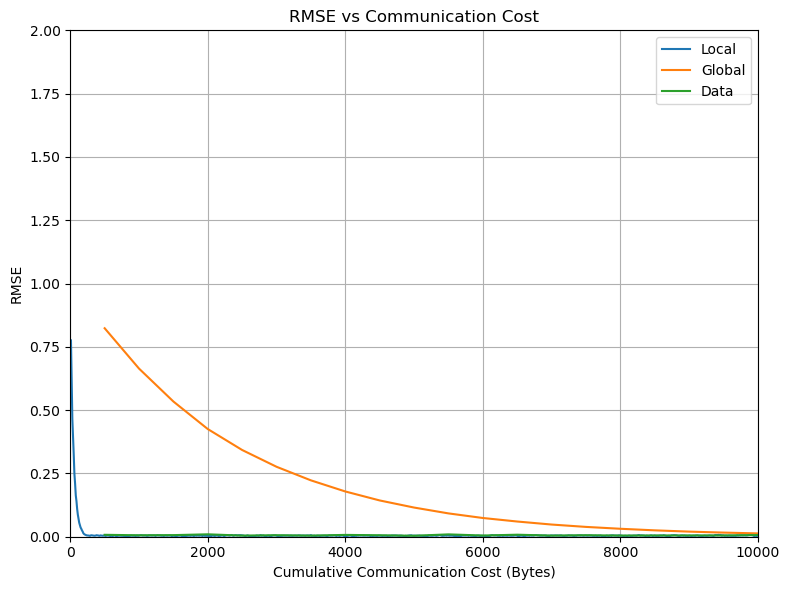

In [22]:
plot_rmse_vs_comm_cost(
    rmse_lists=[ rmse_central_local, rmse_central, rmse_central_data],
    comm_cost_lists=[comm_central_local, comm_central,comm_central],
    labels=["Local", "Global", "Data"],
    save_path="rmse_vs_comm_cost.png"
)